# Mini Project 9 — All-in-One Colab Notebook

This single notebook runs the full project pipeline end to end:
- setup and reproducibility
- data loading and preprocessing
- EDA and class imbalance analysis
- stratified train/validation/test split
- TF-IDF + Logistic Regression baseline with tuning
- DistilBERT fine-tuning with class weights
- side-by-side comparison
- error analysis
- confidence-threshold moderation workflow

Run the cells from top to bottom in Colab. For the transformer section, switch the runtime to **GPU**.


In [1]:
# Install dependencies in Colab
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn requests tqdm torch transformers accelerate sentencepiece

In [2]:
# Imports and configuration
from pathlib import Path
import json
import math
import os
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (8, 5)

SEED = 42
DATA_URL = 'https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/refs/heads/master/data/labeled_data.csv'
DATA_FILENAME = 'labeled_data.csv'
TEXT_COLUMN = 'tweet'
TARGET_COLUMN = 'class'
LABEL_MAP = {0: 'hate_speech', 1: 'offensive_language', 2: 'neither'}
LABEL_ORDER = [0, 1, 2]
TARGET_NAMES = [LABEL_MAP[i] for i in LABEL_ORDER]
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BASELINE_PARAM_GRID = {
    'tfidf__max_features': [10000, 20000, 40000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.5, 1.0, 2.0, 4.0],
}
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
CONFIDENCE_THRESHOLDS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
PROJECT_ROOT = Path('/content/mini_project_9')
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
METRICS_DIR = ARTIFACTS_DIR / 'metrics'
MODELS_DIR = PROJECT_ROOT / 'models'
for p in [DATA_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Device:', device)
print('GPU available:', torch.cuda.is_available())

Project root: /content/mini_project_9
Device: cuda
GPU available: True


In [3]:
# Helper functions
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
HASHTAG_PATTERN = re.compile(r'#(\w+)')
WHITESPACE_PATTERN = re.compile(r'\s+')
NON_ASCII_PATTERN = re.compile(r'[^\x00-\x7F]+')


def download_dataset(force=False):
    out_path = DATA_DIR / DATA_FILENAME
    if out_path.exists() and not force:
        return out_path
    r = requests.get(DATA_URL, timeout=60)
    r.raise_for_status()
    out_path.write_bytes(r.content)
    return out_path


def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = URL_PATTERN.sub(' URL ', text)
    text = MENTION_PATTERN.sub(' USER ', text)
    text = HASHTAG_PATTERN.sub(r' \1 ', text)
    text = NON_ASCII_PATTERN.sub(' ', text)
    text = text.replace('&amp;', ' and ')
    text = re.sub(r"[^a-z0-9\s!?.,'_-]", ' ', text)
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text


def load_dataset(force_download=False):
    csv_path = download_dataset(force=force_download)
    df = pd.read_csv(csv_path)
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    df['label_name'] = df[TARGET_COLUMN].map(LABEL_MAP)
    df['text_raw'] = df[TEXT_COLUMN].astype(str)
    df['text_clean'] = df['text_raw'].apply(clean_text)
    df['char_count'] = df['text_raw'].astype(str).str.len()
    df['word_count'] = df['text_raw'].astype(str).str.split().apply(len)
    return df


def class_distribution_table(df):
    counts = df[TARGET_COLUMN].value_counts().reindex(LABEL_ORDER)
    return pd.DataFrame({
        'label_id': LABEL_ORDER,
        'label_name': [LABEL_MAP[i] for i in LABEL_ORDER],
        'count': counts.values,
        'percentage': (counts.values / counts.values.sum() * 100).round(2),
    })


def sample_examples(df, n_per_class=3, seed=SEED):
    rows = []
    for label_id in LABEL_ORDER:
        subset = df[df[TARGET_COLUMN] == label_id].sample(n=min(n_per_class, (df[TARGET_COLUMN] == label_id).sum()), random_state=seed)
        rows.append(subset[[TARGET_COLUMN, 'label_name', 'text_raw', 'text_clean']])
    return pd.concat(rows).reset_index(drop=True)


def stratified_split(df):
    train_val_df, test_df = train_test_split(
        df, test_size=TEST_SIZE, stratify=df[TARGET_COLUMN], random_state=SEED
    )
    adjusted_val = VAL_SIZE / (1.0 - TEST_SIZE)
    train_df, val_df = train_test_split(
        train_val_df, test_size=adjusted_val, stratify=train_val_df[TARGET_COLUMN], random_state=SEED
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def compute_class_weights(y):
    y = np.array(y)
    counts = np.bincount(y, minlength=len(LABEL_ORDER))
    weights = len(y) / (len(LABEL_ORDER) * np.maximum(counts, 1))
    weights = weights / weights.sum() * len(LABEL_ORDER)
    return torch.tensor(weights, dtype=torch.float32)


def compute_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABEL_ORDER, zero_division=0)
    mp, mr, mf1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    wp, wr, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': mp,
        'macro_recall': mr,
        'macro_f1': mf1,
        'weighted_precision': wp,
        'weighted_recall': wr,
        'weighted_f1': wf1,
    }
    for idx, label_id in enumerate(LABEL_ORDER):
        name = LABEL_MAP[label_id]
        metrics[f'{name}_precision'] = p[idx]
        metrics[f'{name}_recall'] = r[idx]
        metrics[f'{name}_f1'] = f1[idx]
    return metrics


def classification_report_df(y_true, y_pred):
    report = classification_report(
        y_true, y_pred, labels=LABEL_ORDER, target_names=TARGET_NAMES, output_dict=True, zero_division=0
    )
    return pd.DataFrame(report).T


def confusion_matrix_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    return pd.DataFrame(cm, index=TARGET_NAMES, columns=TARGET_NAMES)


def build_comparison_table(results):
    rows = []
    for model_name, metrics in results.items():
        row = {'model': model_name}
        row.update(metrics)
        rows.append(row)
    df = pd.DataFrame(rows)
    preferred = [
        'model', 'accuracy', 'macro_f1', 'weighted_f1',
        'hate_speech_f1', 'offensive_language_f1', 'neither_f1',
        'hate_speech_recall', 'offensive_language_recall', 'neither_recall'
    ]
    others = [c for c in df.columns if c not in preferred]
    return df[preferred + others]


def accuracy_vs_coverage(y_true, y_pred, confidences, thresholds):
    rows = []
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    confidences = np.array(confidences)
    for threshold in thresholds:
        mask = confidences >= threshold
        coverage = float(mask.mean())
        accuracy = np.nan if mask.sum() == 0 else accuracy_score(y_true[mask], y_pred[mask])
        rows.append({
            'threshold': threshold,
            'coverage': coverage,
            'accuracy_at_threshold': accuracy,
            'human_review_rate': 1.0 - coverage,
        })
    return pd.DataFrame(rows)


def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2)


def save_df(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

## 1. Load and inspect the dataset

In [4]:
df = load_dataset(force_download=False)
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate raw tweets:', df['text_raw'].duplicated().sum())
df.head()

Dataset shape: (24783, 11)
Columns: ['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'label_name', 'text_raw', 'text_clean', 'char_count', 'word_count']

Missing values:
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
label_name            0
text_raw              0
text_clean            0
char_count            0
word_count            0
dtype: int64

Duplicate raw tweets: 0


,count,hate_speech,offensive_language,neither,class,tweet,label_name,text_raw,text_clean,char_count,word_count
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,neither,!!! RT @mayasolovely: As a woman you shouldn't...,!!! rt as a woman you shouldn't complain about...,140,25
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive_language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!!!!! rt boy dats cold...tyga dwn bad for cuff...,85,16
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive_language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!!!!!!! rt dawg!!!! rt you ever fuck a bitch a...,120,21
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive_language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,!!!!!!!!! rt she look like a tranny,62,9
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive_language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,!!!!!!!!!!!!! rt the shit you hear about me mi...,137,26


In [5]:
dist_table = class_distribution_table(df)
dist_table

,label_id,label_name,count,percentage
0,0,hate_speech,1430,5.77
1,1,offensive_language,19190,77.43
2,2,neither,4163,16.80


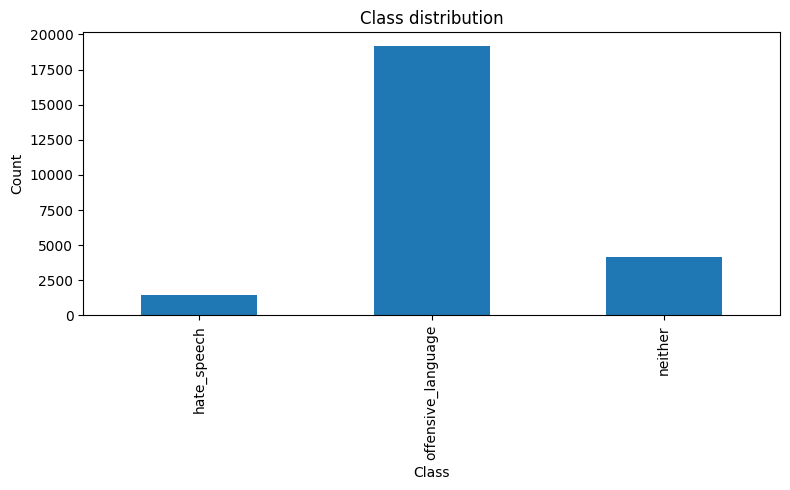

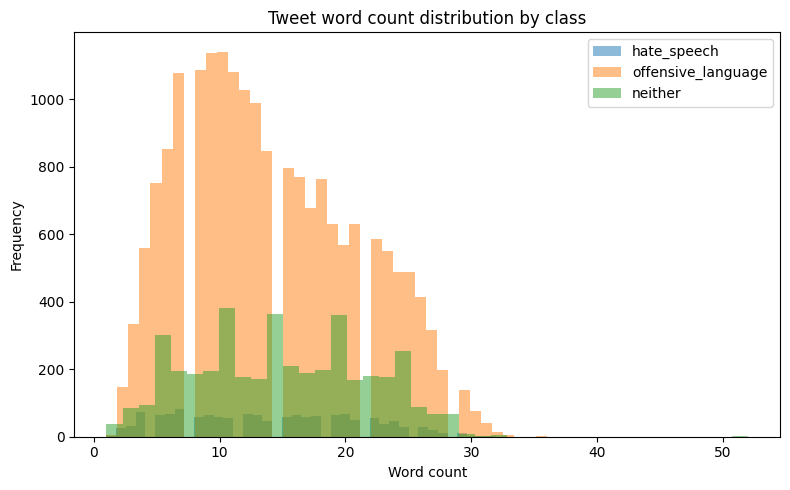

In [6]:
ax = dist_table.plot(kind='bar', x='label_name', y='count', legend=False)
ax.set_title('Class distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=200)
plt.show()

fig, ax = plt.subplots()
for label_id, label_name in LABEL_MAP.items():
    subset = df[df[TARGET_COLUMN] == label_id]['word_count']
    ax.hist(subset, bins=40, alpha=0.5, label=label_name)
ax.set_title('Tweet word count distribution by class')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'word_count_by_class.png', dpi=200)
plt.show()

In [7]:
sample_examples(df, n_per_class=4)

,class,label_name,text_raw,text_clean
0,0,hate_speech,@AustinG1135 I do not like talking to you fagg...,i do not like talking to you faggot and i did ...
1,0,hate_speech,RT @mitchmancuso: @BrantPrintup:What straight ...,rt what straight guys take a picture of themse...
2,0,hate_speech,"@clinchmtn316 @sixonesixband AMERICA today, th...","america today, the rule of thumb is when in do..."
3,0,hate_speech,"@STACCS_WNT_FOLD you tell me, coon.","you tell me, coon."
4,1,offensive_language,Why is it everytime I go to cracker barrel the...,why is it everytime i go to cracker barrel the...
5,1,offensive_language,"Run that nigga, you don't want that nigga, but...","run that nigga, you don't want that nigga, but..."
6,1,offensive_language,I need a girl from Jamaica I can't fuck with t...,i need a girl from jamaica i can't fuck with t...
7,1,offensive_language,RT @ShadowBeatz_Inc: I know you have me blocke...,"rt i know you have me blocked, but next week b..."
8,2,neither,RT @chicagotribune: Chicago will not refund $7...,rt chicago will not refund 7.7 million made fr...
9,2,neither,"Sometimes, even I gotta tell these hoes to gro...","sometimes, even i gotta tell these hoes to gro..."


## 2. Create stratified train / validation / test splits

In [8]:
train_df, val_df, test_df = stratified_split(df)
print('Train shape:', train_df.shape)
print('Validation shape:', val_df.shape)
print('Test shape:', test_df.shape)

save_df(train_df, DATA_DIR / 'train.csv')
save_df(val_df, DATA_DIR / 'val.csv')
save_df(test_df, DATA_DIR / 'test.csv')

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{name.upper()} distribution')
    print(class_distribution_table(part))

Train shape: (17347, 11)
Validation shape: (3718, 11)
Test shape: (3718, 11)

TRAIN distribution
   label_id          label_name  count  percentage
0         0         hate_speech   1001        5.77
1         1  offensive_language  13432       77.43
2         2             neither   2914       16.80

VAL distribution
   label_id          label_name  count  percentage
0         0         hate_speech    215        5.78
1         1  offensive_language   2879       77.43
2         2             neither    624       16.78

TEST distribution
   label_id          label_name  count  percentage
0         0         hate_speech    214        5.76
1         1  offensive_language   2879       77.43
2         2             neither    625       16.81


## 3. TF-IDF + Logistic Regression baseline

In [9]:
def build_baseline_pipeline(**overrides):
    tfidf_params = {
        'max_features': 20000,
        'ngram_range': (1, 2),
        'min_df': 2,
        'sublinear_tf': True,
        'strip_accents': 'unicode',
    }
    clf_params = {
        'C': 2.0,
        'class_weight': 'balanced',
        'max_iter': 2000,
        'solver': 'lbfgs',
    }
    for key, value in overrides.items():
        if key.startswith('tfidf__'):
            tfidf_params[key.split('__', 1)[1]] = value
        elif key.startswith('clf__'):
            clf_params[key.split('__', 1)[1]] = value
    return Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('clf', LogisticRegression(**clf_params)),
    ])


def iter_param_grid(param_grid):
    from itertools import product
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))


def tune_baseline(X_train, y_train, X_val, y_val, param_grid):
    experiments = []
    best_model = None
    best_params = None
    best_metrics = None
    best_score = -1
    for params in iter_param_grid(param_grid):
        model = build_baseline_pipeline(**params)
        model.fit(X_train, y_train)
        val_preds = model.predict(X_val)
        metrics = compute_metrics(y_val, val_preds)
        row = {'accuracy': metrics['accuracy'], 'macro_f1': metrics['macro_f1']}
        row.update(params)
        experiments.append(row)
        if metrics['macro_f1'] > best_score:
            best_score = metrics['macro_f1']
            best_model = model
            best_params = params
            best_metrics = metrics
    experiments_df = pd.DataFrame(experiments).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    return best_model, best_params, best_metrics, experiments_df

In [10]:
best_baseline_model, best_baseline_params, best_baseline_val_metrics, tuning_df = tune_baseline(
    X_train=train_df['text_clean'],
    y_train=train_df[TARGET_COLUMN],
    X_val=val_df['text_clean'],
    y_val=val_df[TARGET_COLUMN],
    param_grid=BASELINE_PARAM_GRID,
)

print('Best validation params:', best_baseline_params)
print('Best validation macro F1:', round(best_baseline_val_metrics['macro_f1'], 4))
tuning_df.head(10)

Best validation params: {'tfidf__max_features': 40000, 'tfidf__ngram_range': (1, 2), 'clf__C': 2.0}
Best validation macro F1: 0.745


,accuracy,macro_f1,tfidf__max_features,tfidf__ngram_range,clf__C
0,0.881926,0.744981,40000,"(1, 2)",2.0
1,0.887036,0.744908,40000,"(1, 2)",4.0
2,0.876278,0.742630,10000,"(1, 2)",2.0
3,0.878967,0.742607,20000,"(1, 2)",2.0
4,0.874126,0.740142,40000,"(1, 2)",1.0
5,0.869822,0.739141,10000,"(1, 2)",1.0
6,0.871974,0.738182,20000,"(1, 2)",1.0
7,0.869285,0.737837,40000,"(1, 2)",0.5
8,0.881119,0.736555,20000,"(1, 2)",4.0
9,0.874933,0.735028,10000,"(1, 2)",4.0


In [11]:
baseline_test_preds = best_baseline_model.predict(test_df['text_clean'])
baseline_test_metrics = compute_metrics(test_df[TARGET_COLUMN], baseline_test_preds)
baseline_report = classification_report_df(test_df[TARGET_COLUMN], baseline_test_preds)
baseline_cm = confusion_matrix_df(test_df[TARGET_COLUMN], baseline_test_preds)

pd.DataFrame([baseline_test_metrics]).T.rename(columns={0: 'baseline_test'})

,baseline_test
accuracy,0.877891
macro_precision,0.707530
macro_recall,0.783625
macro_f1,0.738716
weighted_precision,0.897219
weighted_recall,0.877891
weighted_f1,0.884949
hate_speech_precision,0.372549
hate_speech_recall,0.532710
hate_speech_f1,0.438462


In [12]:
baseline_report

,precision,recall,f1-score,support
hate_speech,0.372549,0.532710,0.438462,214.000000
offensive_language,0.959344,0.893366,0.925180,2879.000000
neither,0.790698,0.924800,0.852507,625.000000
accuracy,0.877891,0.877891,0.877891,0.877891
macro avg,0.707530,0.783625,0.738716,3718.000000
weighted avg,0.897219,0.877891,0.884949,3718.000000


In [13]:
baseline_cm

,hate_speech,offensive_language,neither
hate_speech,114,77,23
offensive_language,177,2572,130
neither,15,32,578


## 4. DistilBERT fine-tuning

In [14]:
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss

DEBUG_MODE = False  # Set True for a quick smoke run
if DEBUG_MODE:
    train_df_run = train_df.sample(n=min(1200, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df_run = val_df.sample(n=min(300, len(val_df)), random_state=SEED).reset_index(drop=True)
    test_df_run = test_df.sample(n=min(300, len(test_df)), random_state=SEED).reset_index(drop=True)
    EPOCHS_RUN = 1
else:
    train_df_run, val_df_run, test_df_run = train_df, val_df, test_df
    EPOCHS_RUN = EPOCHS

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoded = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


def make_loader(texts, labels, tokenizer, batch_size=16, shuffle=False):
    ds = TweetDataset(texts=texts, labels=labels, tokenizer=tokenizer, max_length=MAX_LENGTH)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def run_epoch(model, loader, optimizer, scheduler, device, loss_fn, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_labels, all_preds = [], []
    for batch in tqdm(loader, leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        with torch.set_grad_enabled(training):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
        preds = torch.argmax(logits, dim=1)
        total_loss += loss.item() * labels.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = avg_loss
    return metrics


def train_transformer(model, train_loader, val_loader, device, class_weights, epochs, learning_rate, weight_decay=0.01, warmup_ratio=0.1):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    loss_fn = CrossEntropyLoss(weight=class_weights.to(device))
    history = []
    best_state = None
    best_val_macro_f1 = -1
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer, scheduler, device, loss_fn, training=True)
        val_metrics = run_epoch(model, val_loader, optimizer, None, device, loss_fn, training=False)
        row = {
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_accuracy': val_metrics['accuracy'],
            'train_macro_f1': train_metrics['macro_f1'],
            'val_macro_f1': val_metrics['macro_f1'],
        }
        history.append(row)
        print(row)
        if val_metrics['macro_f1'] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics['macro_f1']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


@torch.no_grad()
def predict_with_confidence(model, loader, device):
    model.eval()
    model.to(device)
    all_labels, all_preds, all_conf, all_probs = [], [], [], []
    for batch in tqdm(loader, leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        confs, preds = torch.max(probs, dim=1)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_conf.extend(confs.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
    return {
        'y_true': np.array(all_labels),
        'y_pred': np.array(all_preds),
        'confidence': np.array(all_conf),
        'probabilities': np.array(all_probs),
    }


print('Runtime device:', device)
print('DEBUG_MODE:', DEBUG_MODE)
print('Train size used:', len(train_df_run))

Runtime device: cuda
DEBUG_MODE: False
Train size used: 17347


In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

train_loader = make_loader(train_df_run['text_clean'], train_df_run[TARGET_COLUMN], tokenizer, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_df_run['text_clean'], val_df_run[TARGET_COLUMN], tokenizer, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_df_run['text_clean'], test_df_run[TARGET_COLUMN], tokenizer, batch_size=BATCH_SIZE, shuffle=False)

class_weights = compute_class_weights(train_df_run[TARGET_COLUMN])
print('Class weights:', class_weights)

transformer_model, history_df = train_transformer(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    class_weights=class_weights,
    epochs=EPOCHS_RUN,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
)

history_df

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

{'epoch': 3, 'train_loss': 0.3813807173902833, 'val_loss': 0.5622668013000693, 'train_accuracy': 0.9296708364558713, 'val_accuracy': 0.9042495965572889, 'train_macro_f1': 0.8288306716532908, 'val_macro_f1': 0.7708156146915869}


  0%|          | 0/1085 [00:00<?, ?it/s]

  0%|          | 0/233 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.30275516465779595, 'val_loss': 0.6870681326545779, 'train_accuracy': 0.9476566553294518, 'val_accuracy': 0.9039806347498656, 'train_macro_f1': 0.8670265767457583, 'val_macro_f1': 0.766405427468995}


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1
0,1,0.666143,0.484230,0.827924,0.897257,0.659418,0.767944
1,2,0.469403,0.559442,0.910705,0.909360,0.789830,0.774993
2,3,0.381381,0.562267,0.929671,0.904250,0.828831,0.770816
3,4,0.302755,0.687068,0.947657,0.903981,0.867027,0.766405


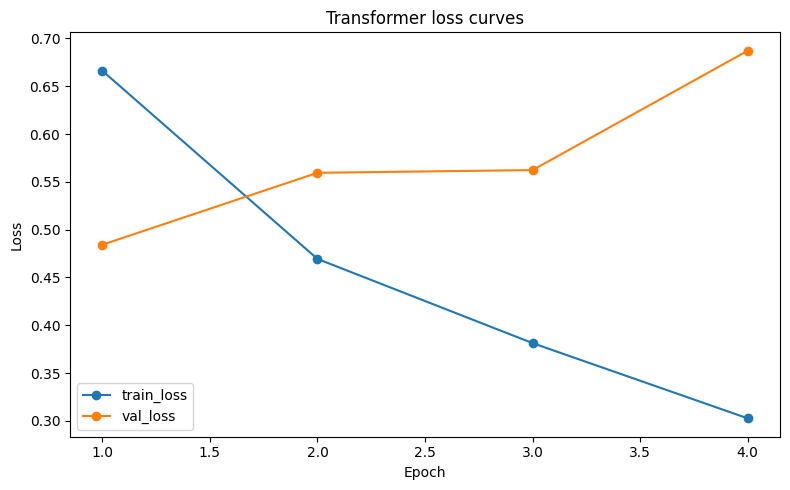

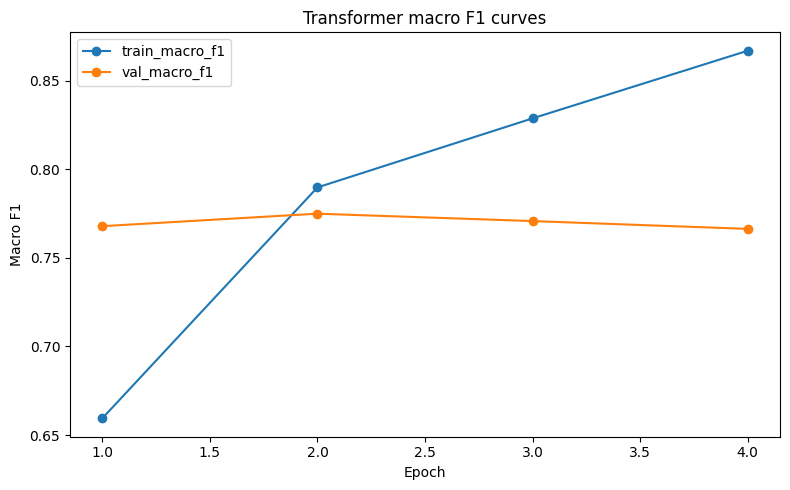

In [16]:
fig, ax = plt.subplots()
ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss')
ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val_loss')
ax.set_title('Transformer loss curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transformer_loss_curves.png', dpi=200)
plt.show()

fig, ax = plt.subplots()
ax.plot(history_df['epoch'], history_df['train_macro_f1'], marker='o', label='train_macro_f1')
ax.plot(history_df['epoch'], history_df['val_macro_f1'], marker='o', label='val_macro_f1')
ax.set_title('Transformer macro F1 curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transformer_macro_f1_curves.png', dpi=200)
plt.show()

In [17]:
pred_out = predict_with_confidence(transformer_model, test_loader, device)
transformer_test_metrics = compute_metrics(pred_out['y_true'], pred_out['y_pred'])
transformer_report = classification_report_df(pred_out['y_true'], pred_out['y_pred'])
transformer_cm = confusion_matrix_df(pred_out['y_true'], pred_out['y_pred'])

pd.DataFrame([transformer_test_metrics]).T.rename(columns={0: 'transformer_test'})

  0%|          | 0/233 [00:00<?, ?it/s]

,transformer_test
accuracy,0.914739
macro_precision,0.773540
macro_recall,0.806357
macro_f1,0.788976
weighted_precision,0.918601
weighted_recall,0.914739
weighted_f1,0.916164
hate_speech_precision,0.495690
hate_speech_recall,0.537383
hate_speech_f1,0.515695


In [ ]:
transformer_report

In [ ]:
transformer_cm

## 5. Side-by-side model comparison

In [20]:
comparison_df = build_comparison_table({
    'tfidf_logreg': baseline_test_metrics,
    'distilbert': transformer_test_metrics,
})
comparison_df

,model,accuracy,macro_f1,weighted_f1,hate_speech_f1,offensive_language_f1,neither_f1,hate_speech_recall,offensive_language_recall,neither_recall,macro_precision,macro_recall,weighted_precision,weighted_recall,hate_speech_precision,offensive_language_precision,neither_precision
0,tfidf_logreg,0.877891,0.738716,0.884949,0.438462,0.925180,0.852507,0.532710,0.893366,0.9248,0.70753,0.783625,0.897219,0.877891,0.372549,0.959344,0.790698
1,distilbert,0.914739,0.788976,0.916164,0.515695,0.948944,0.902290,0.537383,0.936089,0.9456,0.77354,0.806357,0.918601,0.914739,0.495690,0.962156,0.862774


## 6. Error analysis

In [21]:
SLANG_HINTS = {'finna', 'fr', 'tf', 'idk', 'lmao', 'lmfao', 'wtf', "ain't", 'gonna', 'tryna', 'bruh'}
PROFANITY_HINTS = {'bitch', 'shit', 'fuck', 'fucking', 'nigga', 'nigger', 'hoe', 'ass', 'damn'}


def guess_error_category(text, true_label, pred_label):
    t = str(text).lower()
    if 'url' in t or 'user' in t:
        return 'context_loss_from_placeholder_tokens'
    if any(tok in t.split() for tok in SLANG_HINTS):
        return 'slang_or_nonstandard_spelling'
    if '"' in t or "'" in t:
        return 'quoted_or_ambiguous_speech'
    if true_label != pred_label and {true_label, pred_label} <= {0, 1}:
        return 'hate_vs_offensive_boundary'
    if any(tok in t.split() for tok in PROFANITY_HINTS):
        return 'profanity_not_enough_context'
    if '?' in t or '!' in t:
        return 'tone_or_intent_ambiguity'
    return 'possible_annotation_noise_or_context_gap'

errors_df = test_df_run.copy().reset_index(drop=True)
errors_df['y_true'] = pred_out['y_true']
errors_df['y_pred'] = pred_out['y_pred']
errors_df['confidence'] = pred_out['confidence']
errors_df['true_label_name'] = errors_df['y_true'].map(LABEL_MAP)
errors_df['pred_label_name'] = errors_df['y_pred'].map(LABEL_MAP)
errors_df = errors_df[errors_df['y_true'] != errors_df['y_pred']].copy()
errors_df['error_category'] = errors_df.apply(
    lambda row: guess_error_category(row['text_clean'], row['y_true'], row['y_pred']), axis=1
)
errors_df['analysis_notes'] = 'Review and refine this explanation manually for the report.'

print('Total misclassifications:', len(errors_df))
errors_df[['text_raw', 'true_label_name', 'pred_label_name', 'confidence', 'error_category', 'analysis_notes']].head(15)

Total misclassifications: 317


,text_raw,true_label_name,pred_label_name,confidence,error_category,analysis_notes
15,@BrandNewAndrew lmaooo roosters is hot trash b...,offensive_language,neither,0.969684,possible_annotation_noise_or_context_gap,Review and refine this explanation manually fo...
19,@iH8TvvitterHoes @breezyfrmdablok what do you ...,offensive_language,hate_speech,0.932708,quoted_or_ambiguous_speech,Review and refine this explanation manually fo...
68,Because of the message that sends to LGBTQ res...,offensive_language,neither,0.699173,possible_annotation_noise_or_context_gap,Review and refine this explanation manually fo...
80,"""@QUAN1T0: 61% of welfare/government aid is cl...",neither,hate_speech,0.964207,quoted_or_ambiguous_speech,Review and refine this explanation manually fo...
84,@DSwaggin6_ @_JustDavilaa @xaviee_21 @Quise414...,offensive_language,hate_speech,0.963466,hate_vs_offensive_boundary,Review and refine this explanation manually fo...
86,"Man, I'm wish big booty bytches would use some...",offensive_language,neither,0.896417,quoted_or_ambiguous_speech,Review and refine this explanation manually fo...
94,Chiefs fans are the only ones that claim my ta...,offensive_language,neither,0.988290,possible_annotation_noise_or_context_gap,Review and refine this explanation manually fo...
118,RT @FriendlyAssh0le: Todays Horoscope: \n\nyou...,neither,offensive_language,0.978870,quoted_or_ambiguous_speech,Review and refine this explanation manually fo...
123,"""Let's do nips ahoy and spank me maybe""",offensive_language,neither,0.924155,quoted_or_ambiguous_speech,Review and refine this explanation manually fo...
128,Photo: Giving you that trailer park trash. #tr...,neither,hate_speech,0.813170,possible_annotation_noise_or_context_gap,Review and refine this explanation manually fo...


In [22]:
error_summary = errors_df['error_category'].value_counts().rename_axis('error_category').reset_index(name='count')
error_summary

,error_category,count
0,hate_vs_offensive_boundary,123
1,quoted_or_ambiguous_speech,93
2,possible_annotation_noise_or_context_gap,59
3,slang_or_nonstandard_spelling,22
4,tone_or_intent_ambiguity,16
5,profanity_not_enough_context,4


## 7. Confidence thresholds and moderation workflow

In [23]:
coverage_df = accuracy_vs_coverage(
    y_true=pred_out['y_true'],
    y_pred=pred_out['y_pred'],
    confidences=pred_out['confidence'],
    thresholds=CONFIDENCE_THRESHOLDS,
)
coverage_df

,threshold,coverage,accuracy_at_threshold,human_review_rate
0,0.50,0.997310,0.915588,0.002690
1,0.60,0.984400,0.920492,0.015600
2,0.70,0.971490,0.924419,0.028510
3,0.80,0.944325,0.928510,0.055675
4,0.90,0.866864,0.938567,0.133136
5,0.95,0.761162,0.956184,0.238838


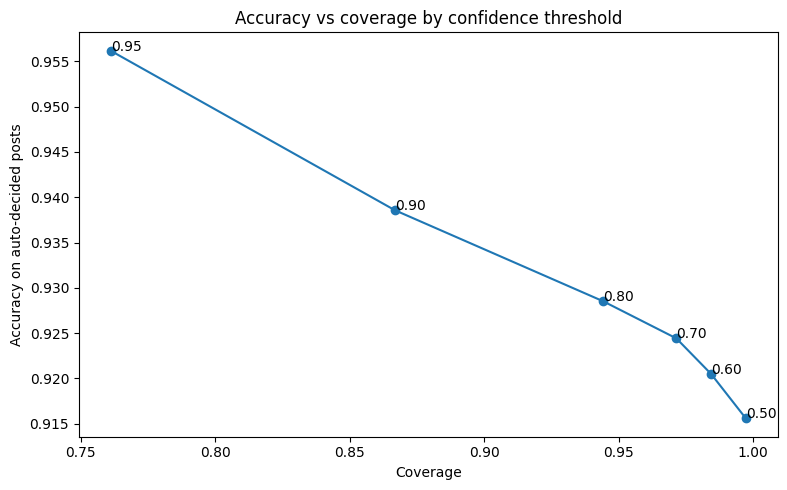

In [24]:
fig, ax = plt.subplots()
ax.plot(coverage_df['coverage'], coverage_df['accuracy_at_threshold'], marker='o')
for _, row in coverage_df.iterrows():
    ax.annotate(f"{row['threshold']:.2f}", (row['coverage'], row['accuracy_at_threshold']))
ax.set_title('Accuracy vs coverage by confidence threshold')
ax.set_xlabel('Coverage')
ax.set_ylabel('Accuracy on auto-decided posts')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_vs_coverage.png', dpi=200)
plt.show()

In [25]:
def apply_moderation_policy(df_predictions, remove_threshold=0.90, approve_threshold=0.90, offensive_review_threshold=0.80):
    dfp = df_predictions.copy()
    actions = []
    for _, row in dfp.iterrows():
        pred = int(row['y_pred'])
        conf = float(row['confidence'])
        if pred == 0 and conf >= remove_threshold:
            action = 'auto_remove'
        elif pred == 2 and conf >= approve_threshold:
            action = 'auto_approve'
        elif pred == 1 and conf >= offensive_review_threshold:
            action = 'human_review_priority'
        else:
            action = 'human_review'
        actions.append(action)
    dfp['moderation_action'] = actions
    return dfp


def moderation_summary(df_predictions, daily_volume=100_000):
    counts = df_predictions['moderation_action'].value_counts(normalize=True).sort_index()
    summary = pd.DataFrame({
        'action': counts.index,
        'share': counts.values,
        'daily_posts': (counts.values * daily_volume).round().astype(int),
    })
    return summary.sort_values(by='share', ascending=False).reset_index(drop=True)

predictions_df = test_df_run.copy().reset_index(drop=True)
predictions_df['y_true'] = pred_out['y_true']
predictions_df['y_pred'] = pred_out['y_pred']
predictions_df['confidence'] = pred_out['confidence']
predictions_df['true_label_name'] = predictions_df['y_true'].map(LABEL_MAP)
predictions_df['pred_label_name'] = predictions_df['y_pred'].map(LABEL_MAP)

policy_df = apply_moderation_policy(predictions_df, remove_threshold=0.90, approve_threshold=0.90, offensive_review_threshold=0.80)
moderation_df = moderation_summary(policy_df, daily_volume=100_000)
moderation_df

,action,share,daily_posts
0,human_review_priority,0.717052,71705
1,auto_approve,0.165949,16595
2,human_review,0.071813,7181
3,auto_remove,0.045186,4519


## 8. Save outputs for the report and README

In [26]:
save_json(best_baseline_params, METRICS_DIR / 'best_baseline_params.json')
save_json(baseline_test_metrics, METRICS_DIR / 'baseline_test_metrics.json')
save_json(transformer_test_metrics, METRICS_DIR / 'transformer_test_metrics.json')
save_df(tuning_df, METRICS_DIR / 'baseline_tuning_results.csv')
save_df(comparison_df, METRICS_DIR / 'model_comparison.csv')
save_df(history_df, METRICS_DIR / 'transformer_history.csv')
save_df(errors_df[['text_raw', 'true_label_name', 'pred_label_name', 'confidence', 'error_category', 'analysis_notes']], METRICS_DIR / 'transformer_misclassifications.csv')
save_df(coverage_df, METRICS_DIR / 'accuracy_vs_coverage.csv')
save_df(policy_df[['text_raw', 'true_label_name', 'pred_label_name', 'confidence', 'moderation_action']], METRICS_DIR / 'moderation_predictions.csv')
save_df(moderation_df, METRICS_DIR / 'moderation_summary.csv')

transformer_model.save_pretrained(MODELS_DIR / 'distilbert_best')
tokenizer.save_pretrained(MODELS_DIR / 'distilbert_best')

print('Saved artifacts to:', PROJECT_ROOT)
print('Figures:', FIGURES_DIR)
print('Metrics:', METRICS_DIR)
print('Model:', MODELS_DIR / 'distilbert_best')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved artifacts to: /content/mini_project_9
Figures: /content/mini_project_9/artifacts/figures
Metrics: /content/mini_project_9/artifacts/metrics
Model: /content/mini_project_9/models/distilbert_best


## 9. Ready-to-write conclusions

Use the tables and files above to write these parts of the report:
- dataset imbalance and why macro F1 matters
- baseline vs transformer comparison
- which classes remain hard to separate
- the main misclassification patterns
- how thresholding changes coverage and review load
- estimated daily human-review volume for 100,000 posts/day

Before final submission, manually refine the `analysis_notes` column in the misclassification CSV so your error analysis sounds specific and human.
